In [1]:
import numpy as np
import tensorflow as tf
import keras
from matplotlib import pyplot as plt
import altair as alt
import os
import pandas as pd

from tqdm import tqdm
from scipy.spatial import distance_matrix
from scipy.linalg import dft
from scipy import fft
from sklearn.manifold import TSNE
import Levenshtein
import networkx as nx
from sklearn import metrics
import matplotlib_venn as venn

alt.data_transformers.disable_max_rows()

2025-09-22 19:05:14.167643: E external/local_xla/xla/stream_executor/plugin_registry.cc:91] Invalid plugin kind specified: FFT
2025-09-22 19:05:19.449601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 19:05:22.126522: E external/local_xla/xla/stream_executor/plugin_registry.cc:91] Invalid plugin kind specified: DNN


DataTransformerRegistry.enable('default')

In [2]:
print("tensorflow:", tf.__version__)
print("keras:", keras.__version__)

tensorflow: 2.16.1
keras: 3.7.0


In [3]:
'''Load the gene data'''
def concatenate_datasets(*datasets) -> tf.data.Dataset:
    ## Function to concatenate a list of dataset objects into one dataset
    out_ds = datasets[0].concatenate(datasets[1])
    if len(datasets) > 2:
        for ds in datasets[2:]:
            out_ds = out_ds.concatenate(ds)
    return out_ds

gene_dataset = tf.data.Dataset.load("../data/gene_sequences/training_dataset")
gene_dataset = gene_dataset.filter(lambda g,d,c: tf.strings.length(g) <= 5000)

2025-09-22 19:06:29.922552: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 63922 MB memory:  -> device: 0, name: AMD Instinct MI250X, pci bus id: 0000:c6:00.0


In [4]:
'''Define paths to models'''
## Models to test
c_name = "lilac-violet-5132"        # done
f_name = "wise-plasma-5134"         # done
fc_name = "bumbling-wind-5135"      # done
done_names = {'f':f_name, 'c':c_name, 'fc':fc_name}

r_name = "ancient-morning-5137"     # checkpoint
rc_name = "glorious-silence-5133"   # checkpoint
fr_name = "peachy-hill-5135"        # checkpoint
frc_name = "hopeful-violet-5138"    # checkpoint
frac_name = "curious-totem-5139"    # checkpoint
chkpt_names = {'r':r_name, 'rc':rc_name, 'fr':fr_name, 'frc':frc_name, 'frac':frac_name}

model_paths = {}

## Check the model files are stored locally 
for _l,_n in done_names.items():
    n_path = f"models/geneAE_{_n}_fold0.keras"
    if not os.path.exists(n_path):
        print(f"{n_path} not found locally")
    else:
        model_paths[_l] = n_path

## Check if the checkpoint files are stored locally
for _l,_n in chkpt_names.items():
    checkpoints = os.listdir(f"models/checkpoints/{_n}_fold0")
    if len(checkpoints) == 0:
        print(f"{_n} has no local checkpoints")
    else:
        chkpt_files = os.listdir(f"models/checkpoints/{_n}_fold0")
        latest_chkpt = sorted(chkpt_files)[-1]
        model_paths[_l] = f"models/checkpoints/{_n}_fold0/{latest_chkpt}"

In [5]:
'''Load the desired model and compute embeddings'''
gene_ae = tf.keras.models.load_model(model_paths['frac'])

## Preprocess the gene data
dataset_cuts = [gene_dataset.shard(5, k) for k in range(5)]
train_set = concatenate_datasets(*dataset_cuts[:-1])
val_set = dataset_cuts[-1]
batch_size = 128
train_set, val_set = gene_ae.preprocess_dataset(train_set, batch_size=batch_size,
                                                validation_data=val_set,
                                                weighted=False,
                                                shuffle=False)
val_preds = gene_ae.predict(val_set)
# val_preds = gene_ae.encode(val_set)
# n_val_embeds = val_embeds.shape[0]

val_embeds, val_cats, val_recons = val_preds


2025-09-22 19:07:18.214400: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


325/325 ━━━━━━━━━━━━━━━━━━━━ 175s 523ms/step


2025-09-22 19:10:13.021710: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/pfs/lustrep4/scratch/project_465001915/rosstheo/genome_transformer_dev/gene_embedding/wandb-env/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [6]:
'''Load some more data'''
gene_data = pd.read_csv("../data/gene_data.csv", low_memory=False)

In [7]:
'''Collect the label data'''
## Initialize the lists to store data
val_genes = []
cog_categories = []
domains = []
reconstruction_targets = []

## Populate the lists
for g,labels in tqdm(val_set):
    val_genes.append(g)

    _domain,_cat,_recon_target = labels
    cog_categories.append(_cat)
    domains.append(_domain)
    reconstruction_targets.append(_recon_target)

## Convert them to arrays
val_genes = np.concatenate(val_genes, axis=0)
cog_categories = np.concatenate(cog_categories, axis=0)
domains = np.concatenate(domains, axis=0)
reconstruction_targets = np.concatenate(reconstruction_targets, axis=0)

325it [00:10, 29.89it/s]


In [8]:
'''Test COG category prediction'''


## Define prediction and label arrays
val_cat_preds = (val_cats > 0.5).astype(int)
correct_mask = np.all(val_cat_preds == cog_categories, axis=1)
print(f"genes completely correct:\t\t {correct_mask.sum():5d}\t ({correct_mask.mean()*100:3.2f}%)")

## Isolate genes that had functional labels
labeled_mask = cog_categories.sum(axis=1) > 0
labeled_preds = val_cat_preds[labeled_mask]
labeled_labels = cog_categories[labeled_mask].astype(int)

full_correct = np.all(labeled_preds == labeled_labels, axis=1)
not_full_corr_mask = ~np.all(labeled_preds == labeled_labels, axis=1)
print(f"labeled genes completely correct:\t {full_correct.sum():5d}\t ({full_correct.mean()*100:3.2f}%)")
# print("percent no pred:", (val_cat_preds.sum(axis=1)==0).mean())


print(f"genes with labels:\t\t\t", 
      f"{(cog_categories.sum(axis=1)!=0).sum():5d}\t",
      f"({(cog_categories.sum(axis=1)!=0).mean()*100:3.2f}%)")
print(f"genes with no prediction:\t\t ",
      f"{(val_cat_preds.sum(axis=1)==0).sum():4d}\t ",
      f"({(val_cat_preds.sum(axis=1)==0).mean()*100:3.2f}%)")

labelled_no_pred = labeled_preds.sum(axis=1) == 0
print(f"genes with labels and no prediction:\t ", 
      f"{labelled_no_pred.sum():4d}\t ",
      f"({labelled_no_pred.mean()*100:3.2f}%)")

## Find all unique combination of COG category
categs = np.asarray([c for c in 'ABCDEFGHIJKLMNOPQTUVWYZ'])
true_combo_vec, pred_combo_vec = [], []

for ix in range(len(cog_categories)):
    pred_row = val_cat_preds[ix,:]
    true_row = cog_categories[ix,:]

    pred_index = np.where(pred_row)[0]
    true_index = np.where(true_row)[0]
    
    pred_combo = "".join(sorted(categs[pred_index]))
    true_combo = "".join(sorted(categs[true_index]))

    pred_combo_vec.append(pred_combo)
    true_combo_vec.append(true_combo)

# Find F1 scores for each combination
pred_combo_set = set(pred_combo_vec)
true_combo_set = set(true_combo_vec)
combo_index = sorted(list( pred_combo_set | true_combo_set ))
combo_df = pd.DataFrame(0, index=combo_index, columns=["labels","preds"])

for combo in combo_df.index:
    m_label = np.asarray(true_combo_vec) == combo
    m_preds = np.asarray(pred_combo_vec) == combo
    combo_df.loc[combo, "labels"] = m_label.sum()
    combo_df.loc[combo, 'preds'] = m_preds.sum()
    # if _m.sum() > 0:
    #     preds = val_cat_preds[_m]
    #     trues = cog_categories[_m]


# # ## Find how many genes with label predictions have no predicted function
# # print(pd.value_counts(val_cat_preds.sum(axis=1), normalize=True))
# # print(pd.value_counts(cog_categories.sum(axis=1), normalize=True))


categ_df = pd.DataFrame(index=categs, columns=["Count", "F1", "Precision", "Recall", "Accuracy"])

for c in range(val_cats.shape[1]):
    # _true = cog_categories[:,c]
    _true = labeled_labels[:,c]
    cat = categs[c]
    if _true.sum() != 0:
        # _pred = val_cat_preds[:,c]
        _pred = labeled_preds[:,c]

        categ_df.loc[cat,"Count"] = _true.sum()
        categ_df.loc[cat,"F1"] = metrics.f1_score(_true,_pred)
        categ_df.loc[cat,"Precision"] = metrics.precision_score(_true,_pred)
        categ_df.loc[cat,"Recall"] = metrics.recall_score(_true,_pred)
        categ_df.loc[cat,"Accuracy"] = metrics.accuracy_score(_true,_pred)        

# combo_df
categ_df

genes completely correct:		 30754	 (73.93%)
labeled genes completely correct:	 25223	 (91.55%)
genes with labels:			 27551	 (66.23%)
genes with no prediction:		  7015	  (16.86%)
genes with labels and no prediction:	  1484	  (5.39%)


,Count,F1,Precision,Recall,Accuracy
A,NaN,NaN,NaN,NaN,NaN
B,1,1.0,1.0,1.0,1.0
C,1086,0.955896,0.997,0.918048,0.996661
D,617,0.918315,0.978022,0.865478,0.996552
E,2126,0.958798,0.989,0.930386,0.99383
F,1061,0.965551,0.995,0.937795,0.997423
G,4294,0.957823,0.977686,0.938752,0.987115
H,705,0.967225,0.994012,0.941844,0.998367
I,964,0.953961,0.985619,0.924274,0.996879
J,1452,0.978442,0.988062,0.969008,0.99775


100%|██████████| 49/49 [00:22<00:00,  2.15it/s]


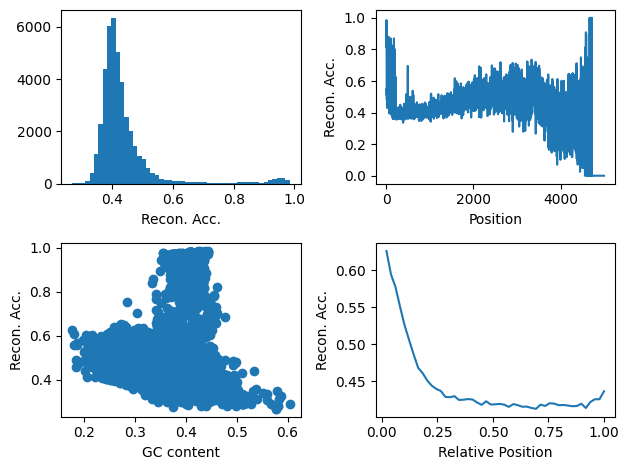

In [24]:
'''Test reconstructions'''

## Define the vocabulary and the reconstruction indices
vocab = gene_ae.encoder.vocabulary
val_recon_idx = np.argmax(val_recons, axis=2)

## Compute the gene lengths and the reconstruction accuracies per gene
true_tokens = val_recon_idx == reconstruction_targets
mask = reconstruction_targets != 0
gene_lens = mask.sum(axis=1)
gene_accs = true_tokens.sum(axis=1) / gene_lens

## Compute the GC content of the genes
# recon_targets_onehot = keras.utils.to_categorical(reconstruction_targets)
c_mask = reconstruction_targets == 4
g_mask = reconstruction_targets == 5
gc_mask = c_mask | g_mask
gc_frac = gc_mask.sum(axis=1) / mask.sum(axis=1)

## Compute the reconstruction accuracy per absolute position
nt_accs = true_tokens.sum(axis=0) / (mask.sum(axis=0)+1e-6)

## Compute the reconstruction accuracy per relative position
pos_counter = np.tile(np.arange(1,val_recon_idx.shape[1]+1)[None,:], 
                      (val_recon_idx.shape[0],1))
rel_pos = pos_counter / gene_lens[:,None]
rel_pos *= mask

bins = np.linspace(0,1,50)
bin_accs = []
for ix in tqdm(range(len(bins)-1)):
    b1 = bins[ix]
    b2 = bins[ix+1]

    b_mask = (rel_pos > b1) & (rel_pos <= b2)
    n_masked = b_mask.sum().sum()
    b_correct = true_tokens[b_mask]
    b_acc = b_correct.mean()
    # b_correct = mask[b_mask]
    # print(b_correct.sum().sum(), (~b_correct.sum().sum()), b_correct.size)
    # b_acc = np.mean(b_correct)
    bin_accs.append(b_acc)

fig,ax = plt.subplots(2,2)
ax[0,0].hist(gene_accs, bins=50)
ax[0,0].set_xlabel("Recon. Acc.")

ax[0,1].plot(nt_accs)
ax[0,1].set_xlabel("Position"); ax[0,1].set_ylabel("Recon. Acc.")

ax[1,1].plot(bins[1:], bin_accs)
ax[1,1].set_xlabel("Relative Position"); ax[1,1].set_ylabel("Recon. Acc.")

ax[1,0].scatter(gc_frac, gene_accs)
ax[1,0].set_xlabel("GC content"); ax[1,0].set_ylabel("Recon. Acc.")

plt.tight_layout()

In [31]:
'''Test clustering'''

## Make a graph describing the co-occurance of domains
n_domains = domains.shape[1]
print((domains.sum(axis=0)!=0).sum())

## Define a matrix of the edge weights
graph_matrix_count = np.zeros((n_domains, n_domains), dtype=int)
for vec in tqdm(domains):
    if vec.sum() > 1:
        pos_jx = np.where(vec)[0]
        mesh_i, mesh_j = np.meshgrid(pos_jx, pos_jx)
        graph_matrix_count[mesh_i.ravel(), mesh_j.ravel()] += 1

np.fill_diagonal(graph_matrix_count, 0)
graph_matrix_frac = graph_matrix_count / len(domains)

## Create the graph
rows,cols = np.where(graph_matrix_frac)
weights = graph_matrix_frac[rows,cols]
edges = zip(rows.tolist(), cols.tolist(), weights.tolist())
domain_graph = nx.Graph()
domain_graph.add_weighted_edges_from(edges)
# nx.draw_shell(domain_graph, node_size=10)
# plt.show()

3570


100%|██████████| 41600/41600 [00:01<00:00, 41363.42it/s]


In [11]:
# '''Subsample the dataset'''
# print(cog_categories.sum(axis=0))

# ## mask the genes and embeddings
# # mask = cog_categories[:,3].astype(bool)           # mask by COG category 3 (C)
# # mask = cog_categories[:,6].astype(bool)           # mask by COG category 6 (G)
# # mask = cog_categories[:,13].astype(bool)           # mask by COG category 13 (M)
# # mask = cog_categories[:,19].astype(bool)           # mask by COG category 19 (V)
# # mask = cog_categories[:,20].astype(bool)           # mask by COG category 20 (W)
# mask_ix = np.random.choice(n_val_embeds, size=(1000), replace=False)   # mask 1000 random samples
# mask = np.zeros((val_embeds.shape[0]), dtype=bool)
# mask[mask_ix] = True
# print(mask.sum())
# masked_embeddings = val_embeds[mask,:]
# masked_genes = val_genes[mask]
# masked_domains = domains[mask,:].astype(bool)
# masked_categories = cog_categories[mask,:].astype(bool)

# ## Compute pairwise distances
# edit_dists = []
# l2_dists = []
# shared_domains = []
# shared_cats = []

# for i in tqdm(range(sum(mask))):
#     ei = masked_embeddings[i,:]
#     gi = masked_genes[i]
#     di = masked_domains[i,:]
#     ci = masked_categories[i,:]
#     for j in range(i+1, sum(mask)):
#         ej = masked_embeddings[j,:]
#         gj = masked_genes[j]
#         dj = masked_domains[j,:]
#         cj = masked_categories[j,:]

#         dist_e = np.linalg.norm(ei - ej, ord=2)
#         dist_g = Levenshtein.distance(gi,gj)
#         n_shared_d = np.logical_and(di,dj).sum()
#         n_shared_c = np.logical_and(ci,cj).sum()

#         l2_dists.append(dist_e)
#         edit_dists.append(dist_g)
#         shared_domains.append(n_shared_d)
#         shared_cats.append(n_shared_c)

In [12]:
# # %matplotlib notebook
# df = pd.DataFrame({"embedding_dist":l2_dists,
#                    "edit_dist":edit_dists,
#                    "shared_domains":shared_domains,
#                    "shared_category":shared_cats})
# color_column = "shared_category"

# selection = alt.selection_point(fields=[color_column], bind='legend')
# alt.Chart(df).mark_point(size=0.5).encode(
#     x = "edit_dist:Q",
#     y = "embedding_dist:Q",
#     color = f"{color_column}:N",
#     opacity=alt.when(selection).then(alt.value(1)).otherwise(alt.value(0.01))
# ).add_params(
#     selection
# )


# # fig,ax = plt.subplots(1,1,subplot_kw={"projection":"3d"})
# # ax.scatter(l2_dists, edit_dists, shared_domains)

# # c1 = alt.Chart(df).mark_point(size=0.5).encode(
# #     x = "edit_dist:Q",
# #     y = "embedding_dist:Q",
# # )
# # c2 = alt.Chart(df).mark_point(size=0.5).encode(
# #     x = "shared_domains:Q",
# #     y = "embedding_dist:Q",
# # )
# # c3 = alt.Chart(df).mark_point(size=0.5).encode(
# #     x = "shared_category:Q",
# #     y = "embedding_dist:Q",
# # )
# # c1 | c2 | c3

In [13]:
# '''Test correlations'''
# from scipy.stats import pearsonr

# leven_l2_test = pearsonr(edit_dists, l2_dists, alternative="greater")
# domain_l2_test = pearsonr(shared_domains, l2_dists, alternative="less")
# cat_l2_test = pearsonr(shared_cats, l2_dists, alternative="less")


# print("levenshtein:", leven_l2_test.pvalue)
# print("domain:", domain_l2_test.pvalue)
# print("category:", cat_l2_test.pvalue)

In [14]:
# '''Evaluate clusters by domain'''
# cluster_means = []
# max_intras = []

# for _d in tqdm(range(domains.shape[1])):
#     _m = domains[:,_d].astype(bool)
#     if _m.sum() != 0:
#         masked_e = val_embeds[_m,:]
#         cluster_means.append(masked_e.mean(axis=0))
#         dm = distance_matrix(masked_e, masked_e)
#         max_intras.append(dm.max())

# cluster_means = np.stack(cluster_means, axis=0)
# # mean_dm = distance_matrix(cluster_means, cluster_means)
# # min_inters = mean_dm


In [15]:
# # cluster_means.shape
# mean_dm = distance_matrix(cluster_means, cluster_means)


In [16]:
# mean_dm_nozero = mean_dm.copy()
# mean_dm_nozero[mean_dm==0] = mean_dm.max()
# min_inters = mean_dm_nozero.min(axis=0)

In [17]:
# plt.scatter(max_intras, min_inters)
# plt.xlabel("maximum intra-cluster distance")
# plt.ylabel("minimum inter-cluster distance")

In [18]:
# '''Print all van genes'''
# van_genes = set([])
# for _g in tqdm(gene_data['gene_name']):
#     if isinstance(_g, str):
#         if 'van' in _g:
#             van_genes.add(_g)

# print(sorted(list(van_genes)))

In [19]:
# '''Get all scaffolds and gff files with van genes'''

# van_scaffolds = {}
# van_gffs = {}
# for _g in van_genes:
#     van_scaffolds[_g] = set(gene_data.loc[gene_data["gene_name"]==_g,'scaffold_name'].tolist())
#     van_gffs[_g] = set(gene_data.loc[gene_data["gene_name"]==_g,'gff_file'].tolist())

# for key,val in van_gffs.items():
#     print(f"{key}:", len(val))

# # vanHAX = vanH_seqs & vanA_seqs & vanX_seqs
# vanHAXY = van_gffs['vanH'] & van_gffs['vanA'] & van_gffs['vanX'] & van_gffs['vanY']

# vanB_cluster = (van_gffs['vanYB'] | van_gffs['vanYB_1'] | van_gffs['vanYB_2']) & van_gffs['vanW'] & \
#                 van_gffs['vanH'] & van_gffs['vanB'] & van_gffs['vanXB']


# print()
# print('vanHAX:', len(vanHAXY))
# print('vanB_cluster:', len(vanB_cluster))

In [20]:
# '''Get the dna sequences to try'''
# # test_gff = "51269075"
# test_gff = list(vanHAXY)
# _df = gene_data.set_index(['gff_file','gene_name'])

# test_vanH = _df.loc[(test_gff, "vanH"), 'dna_sequence'].str.encode('utf-8').to_numpy()
# test_vanA = _df.loc[(test_gff, "vanA"), 'dna_sequence'].str.encode('utf-8').to_numpy()
# test_vanX = _df.loc[(test_gff, "vanX"), 'dna_sequence'].str.encode('utf-8').to_numpy()
# test_vanY = _df.loc[(test_gff, "vanY"), 'dna_sequence'].str.encode('utf-8').to_numpy()

# vanH_embeds = gene_ae.encode(tf.convert_to_tensor(test_vanH))
# vanA_embeds = gene_ae.encode(tf.convert_to_tensor(test_vanA))
# vanX_embeds = gene_ae.encode(tf.convert_to_tensor(test_vanX))
# vanY_embeds = gene_ae.encode(tf.convert_to_tensor(test_vanY))

In [21]:
# fig,ax = plt.subplots(2,2)

# pH = ax[0,0].imshow(distance_matrix(vanH_embeds, vanH_embeds))
# pA = ax[0,1].imshow(distance_matrix(vanA_embeds, vanA_embeds))
# pX = ax[1,0].imshow(distance_matrix(vanX_embeds, vanX_embeds))
# pY = ax[1,1].imshow(distance_matrix(vanY_embeds, vanY_embeds))
# plt.colorbar(pH, ax=ax[0,0])
# plt.colorbar(pA, ax=ax[0,1])
# plt.colorbar(pX, ax=ax[1,0])
# plt.colorbar(pY, ax=ax[1,1])
# ax[0,0].set_title("vanH")
# ax[0,1].set_title("vanA")
# ax[1,0].set_title("vanX")
# ax[1,1].set_title("vanY")

# for a in ax.ravel():
#     a.set_axis_off()
# plt.tight_layout()

In [22]:
# '''Find the nucleotide difference between different alleles'''


# ## Isolate the alleles to observe
# n_genes = len(test_vanY)

# ## Get levenshtein distance between alleles and distance between embeddings
# lev_dists = []
# emb_dists = []
# for ix in tqdm(range(n_genes)):
#     gi = test_vanA[ix]
#     ei = vanA_embeds[ix,:]

#     for jx in range(ix+1, n_genes):
#         gj = test_vanA[jx]
#         ej = vanA_embeds[jx,:]

#         g_dist = levenshteinDistance(gi,gj)
#         e_dist = np.linalg.norm(ei-ej)
#         lev_dists.append(g_dist)
#         emb_dists.append(e_dist)

In [23]:
# '''Plot the embedding vs levenshtein distances'''
# plt.scatter(lev_dists, emb_dists)